In [2]:
# Backtest the actual portfolio performance of the risk-based dynamic allocation strategy vs a static equal-weight benchmark

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

data_path = os.path.expanduser("~/Desktop/SentriVaR-500/data")

# Load saved data
prices = pd.read_csv(f"{data_path}/prices.csv", index_col="Date", parse_dates=True)
copula_scores = pd.read_csv(f"{data_path}/copula_risk_scores.csv", index_col="Date", parse_dates=True)

returns = prices.pct_change().dropna()
TICKERS = ["AAPL", "GOOGL", "JPM", "MSFT", "SOXX"]

print("Loaded")
print(f"Prices: {prices.shape}")
print(f"Copula scores: {copula_scores.shape}")

Loaded
Prices: (2151, 5)
Copula scores: (2115, 5)


In [3]:
# Step 1. Simplified daily allocation weights based on portfolio-level risk
def compute_daily_weights(copula_score, regime):
    if regime == 0: # normal
        cash_ratio = max(0, copula_score * 0.2)
    elif regime == 1: # elevated
        cash_ratio = max(0.1, copula_score * 0.4)
    else: # crisis
         cash_ratio = max(0.3, copula_score * 0.6)

    equity_ratio = 1 - cash_ratio
    per_ticker_weight = equity_ratio / len(TICKERS)
    return per_ticker_weight, cash_ratio

# Build a DataFrame of daily weights
weights_df = copula_scores.apply(
    lambda row: compute_daily_weights(row["copula_risk_score"], row["regime"]),
    axis=1, result_type="expand"
)
weights_df.columns = ["per_ticker_weight", "cash_ratio"]

print("Daily weights sample:")
print(weights_df.head())
print(f"\nCash ratio stats:")
print(weights_df["cash_ratio"].describe().round(4))

Daily weights sample:
            per_ticker_weight  cash_ratio
Date                                     
2018-01-31           0.140000    0.300000
2018-02-01           0.140000    0.300000
2018-02-02           0.174872    0.125640
2018-02-05           0.158255    0.208724
2018-02-06           0.166815    0.165925

Cash ratio stats:
count    2115.0000
mean        0.1570
std         0.1330
min         0.0549
25%         0.0621
50%         0.0847
75%         0.3000
max         0.6000
Name: cash_ratio, dtype: float64


In [4]:
# Step 2. Calculate daily strategy returns using yesterday's weights
combined = returns[TICKERS].join(weights_df, how="inner")

# Shift weights by 1 day: today's return uses YESTERDAY's computed weights
combined["per_ticker_weight_lag"] = combined["per_ticker_weight"].shift(1)
combined["cash_ratio_lag"] = combined["cash_ratio"].shift(1)
combined = combined.dropna()

# Strategy daily return = sum(ticker weight * ticker return) + cash * 0 (assume cash earns 0)
combined["strategy_return"] = (
    combined[TICKERS].mul(combined["per_ticker_weight_lag"], axis=0).sum(axis=1)
)

# Benchmark: static equal weight (1/5 each), no cash buffer, no rebalancing drift considered
combined["benchmark_return"] = combined[TICKERS].mean(axis=1)

print("Daily returns sample:")
print(combined[["strategy_return", "benchmark_return"]].head())
print(f"\nStrategy return stats:")
print(combined["strategy_return"].describe().round(4))
print(f"\nBenchmark return stats:")
print(combined["benchmark_return"].describe().round(4))

Daily returns sample:
            strategy_return  benchmark_return
Date                                         
2018-02-01        -0.000125         -0.000179
2018-02-02        -0.024021         -0.034315
2018-02-05        -0.037067         -0.042393
2018-02-06         0.026427          0.033398
2018-02-07        -0.013621         -0.016331

Strategy return stats:
count    2114.0000
mean        0.0008
std         0.0114
min        -0.0587
25%        -0.0054
50%         0.0012
75%         0.0078
max         0.0513
Name: strategy_return, dtype: float64

Benchmark return stats:
count    2114.0000
mean        0.0010
std         0.0158
min        -0.1389
25%        -0.0066
50%         0.0014
75%         0.0093
max         0.1284
Name: benchmark_return, dtype: float64


In [5]:
# Step 3. Calculate cumulative performance, Sharpe, and Max Drawdown for both

def calculate_performance(daily_returns, name):
    cumulative = (1 + daily_returns).cumprod()
    total_return = (cumulative.iloc[-1] - 1) * 100
    sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)

    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    mdd = drawdown.min() * 100

    print(f"\n{name}")
    print(f"  Total return:  {total_return:.1f}%")
    print(f"  Sharpe ratio:  {sharpe:.3f}")
    print(f"  Max drawdown:  {mdd:.1f}%")

    return cumulative

strategy_cum = calculate_performance(combined["strategy_return"], "Strategy (risk-adaptive)")
benchmark_cum = calculate_performance(combined["benchmark_return"], "Benchmark (equal-weight, no rebalancing)")


Strategy (risk-adaptive)
  Total return:  409.8%
  Sharpe ratio:  1.161
  Max drawdown:  -26.0%

Benchmark (equal-weight, no rebalancing)
  Total return:  559.6%
  Sharpe ratio:  1.025
  Max drawdown:  -32.7%


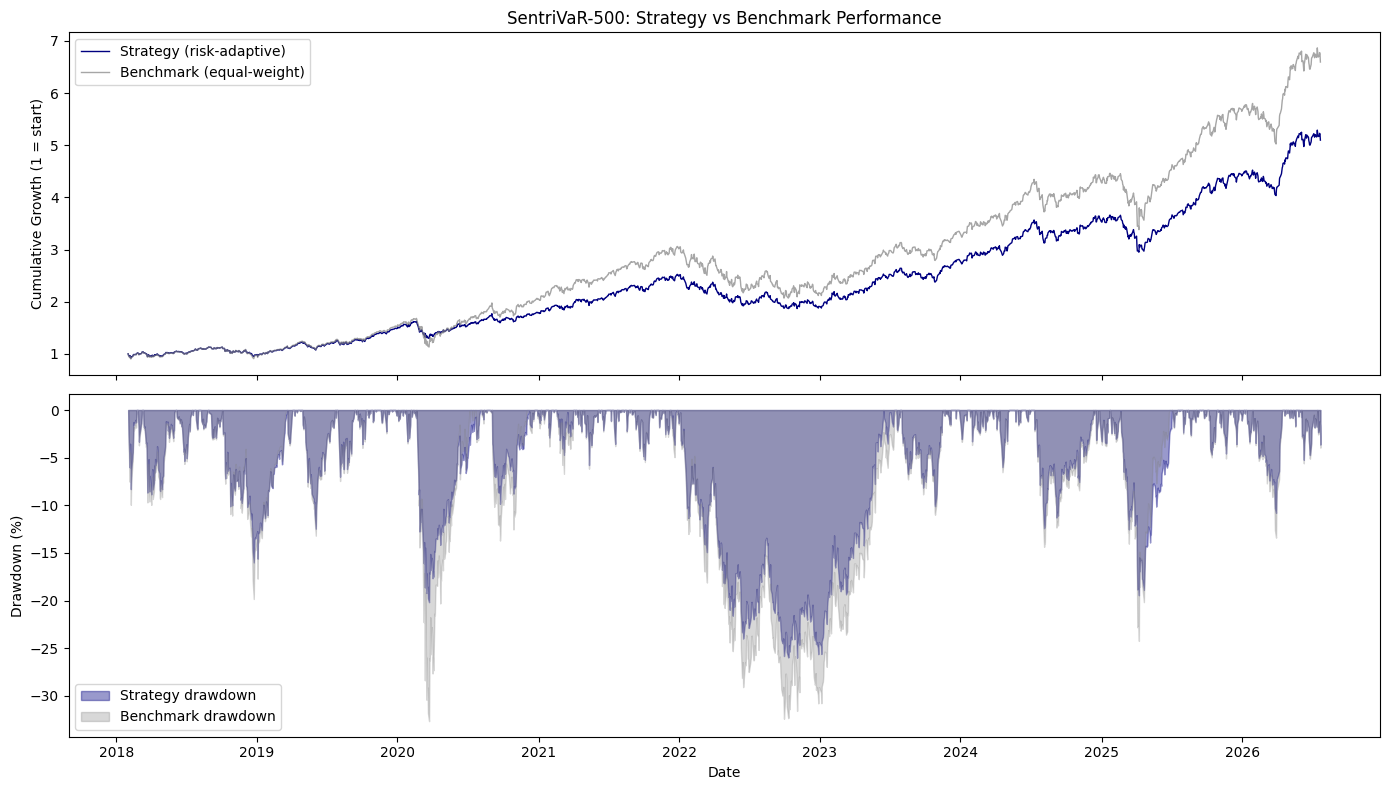

Saved: strategy_backtest.png


In [6]:
# Step 4. Visualize cumulative performance comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(strategy_cum.index, strategy_cum, color="navy", linewidth=1, label="Strategy (risk-adaptive)")
ax1.plot(benchmark_cum.index, benchmark_cum, color="gray", linewidth=1, alpha=0.7, label="Benchmark (equal-weight)")
ax1.set_ylabel("Cumulative Growth (1 = start)")
ax1.set_title("SentriVaR-500: Strategy vs Benchmark Performance")
ax1.legend(loc="upper left")

# Drawdown comparison
strategy_dd = (strategy_cum - strategy_cum.cummax()) / strategy_cum.cummax() * 100
benchmark_dd = (benchmark_cum - benchmark_cum.cummax()) / benchmark_cum.cummax() * 100

ax2.fill_between(strategy_dd.index, strategy_dd, 0, color="navy", alpha=0.4, label="Strategy drawdown")
ax2.fill_between(benchmark_dd.index, benchmark_dd, 0, color="gray", alpha=0.3, label="Benchmark drawdown")
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Date")
ax2.legend(loc="lower left")

plt.tight_layout()
plt.savefig(f"{data_path}/strategy_backtest.png", dpi=150)
plt.show()
print("Saved: strategy_backtest.png")

In [7]:
# Step 5. Save final backtest results
results_summary = pd.DataFrame({
    "Metric": ["Total Return (%)", "Sharpe Ratio", "Max Drawdown (%)"],
    "Strategy": [409.8, 1.161, -26.0],
    "Benchmark": [559.6, 1.025, -32.7]
})
results_summary.to_csv(f"{data_path}/strategy_backtest_results.csv", index=False)
print("Saved: strategy_backtest_results.csv")
print(results_summary)

Saved: strategy_backtest_results.csv
             Metric  Strategy  Benchmark
0  Total Return (%)   409.800    559.600
1      Sharpe Ratio     1.161      1.025
2  Max Drawdown (%)   -26.000    -32.700
